In [1]:
print("Project environment ready")


Project environment ready


In [2]:
import numpy as np
import pandas as pd

speeds = [10,20,30,40,50,60,80]
distances = [2,5,10,15,20,30,40]
closing_vel = [2,5,8,10,15,20]
road = [0,1,2]

data = []

for v in speeds:
    for d in distances:
        for cv in closing_vel:
            for r in road:
                
                v_rel = cv/3.6      # kmph → m/s
                ttc = d / v_rel
                
                if r == 1:
                    ttc = ttc * 0.8
                elif r == 2:
                    ttc = ttc * 0.6
                
                if ttc > 3:
                    label = 0
                elif ttc > 1.5:
                    label = 1
                else:
                    label = 2
                    
                data.append([v,d,cv,ttc,r,label])

df = pd.DataFrame(data,
                  columns=["speed","distance","closing_vel","ttc","road","risk"])

df


,speed,distance,closing_vel,ttc,road,risk
0,10,2,2,3.600,0,0
1,10,2,2,2.880,1,1
2,10,2,2,2.160,2,1
3,10,2,5,1.440,0,2
4,10,2,5,1.152,1,2
...,...,...,...,...,...,...
877,80,40,15,7.680,1,0
878,80,40,15,5.760,2,0
879,80,40,20,7.200,0,0
880,80,40,20,5.760,1,0


In [3]:
df.to_csv("ttc_dataset.csv", index=False)

In [4]:
df.shape

(882, 6)

In [5]:
from sklearn.model_selection import train_test_split

X = df[["speed","distance","closing_vel","ttc","road"]]
y = df["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((705, 5), (177, 5))

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
acc

1.0

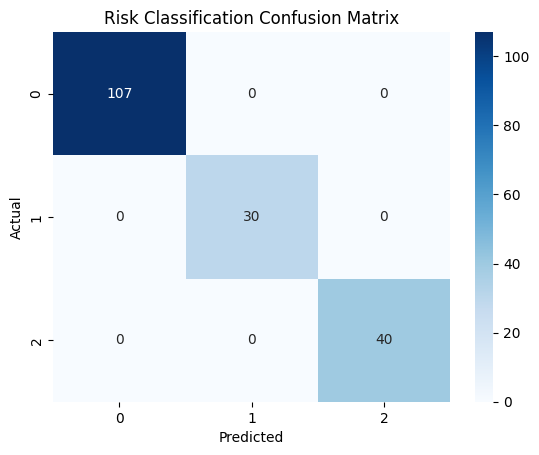

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Risk Classification Confusion Matrix")
plt.show()

In [9]:
from sklearn.tree import export_text

tree = model.estimators_[0]

rules = export_text(tree, feature_names=list(X.columns))
print(rules)

|--- closing_vel <= 6.50
|   |--- distance <= 3.50
|   |   |--- closing_vel <= 3.50
|   |   |   |--- ttc <= 3.24
|   |   |   |   |--- class: 1.0
|   |   |   |--- ttc >  3.24
|   |   |   |   |--- class: 0.0
|   |   |--- closing_vel >  3.50
|   |   |   |--- class: 2.0
|   |--- distance >  3.50
|   |   |--- distance <= 7.50
|   |   |   |--- speed <= 45.00
|   |   |   |   |--- ttc <= 3.24
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- ttc >  3.24
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- speed >  45.00
|   |   |   |   |--- speed <= 55.00
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- speed >  55.00
|   |   |   |   |   |--- class: 0.0
|   |   |--- distance >  7.50
|   |   |   |--- class: 0.0
|--- closing_vel >  6.50
|   |--- distance <= 7.50
|   |   |--- closing_vel <= 9.00
|   |   |   |--- ttc <= 1.57
|   |   |   |   |--- class: 2.0
|   |   |   |--- ttc >  1.57
|   |   |   |   |--- class: 1.0
|   |   |--- closing_vel >  9.00
|   |   |   |--- road <= 0.50
|   

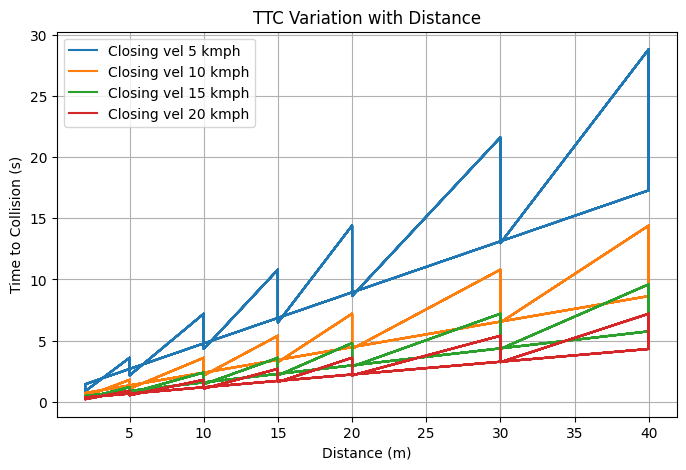

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for cv in [5,10,15,20]:
    ttc = df[df["closing_vel"]==cv]["ttc"]
    dist = df[df["closing_vel"]==cv]["distance"]
    
    plt.plot(dist, ttc, label=f"Closing vel {cv} kmph")

plt.xlabel("Distance (m)")
plt.ylabel("Time to Collision (s)")
plt.title("TTC Variation with Distance")
plt.legend()
plt.grid()

plt.show()

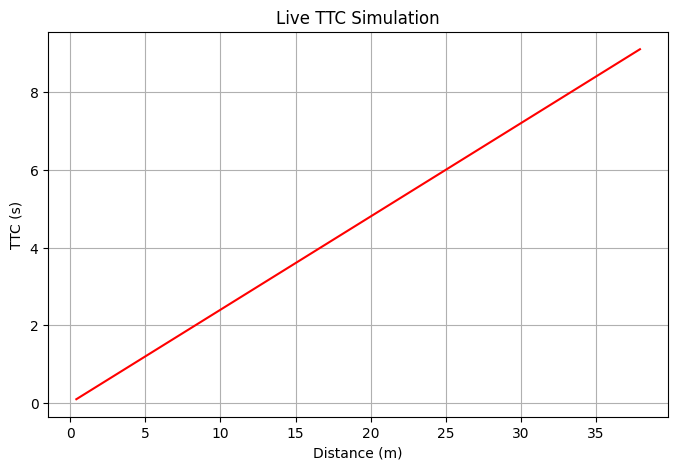

In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

distance = 40
closing_speed = 15

ttc_values = []
dist_values = []

for i in range(50):
    
    distance = distance - (closing_speed/3.6)*0.5
    
    if distance <= 0:
        break
        
    ttc = distance / (closing_speed/3.6)
    
    ttc_values.append(ttc)
    dist_values.append(distance)
    
    clear_output(wait=True)
    
    plt.figure(figsize=(8,5))
    plt.plot(dist_values, ttc_values, color="red")
    plt.xlabel("Distance (m)")
    plt.ylabel("TTC (s)")
    plt.title("Live TTC Simulation")
    plt.grid()
    
    plt.show()
    
    time.sleep(0.3)

In [12]:
print("Serial Data Format Design")

format_example = "45120,180.3,22.5,2.88,3.12,1"

fields = [
    "timestamp_ms",
    "distance_cm",
    "closing_speed_kmh",
    "ttc_basic_s",
    "ttc_extended_s",
    "risk_class"
]

for f in fields:
    print("-", f)

Serial Data Format Design
- timestamp_ms
- distance_cm
- closing_speed_kmh
- ttc_basic_s
- ttc_extended_s
- risk_class


In [13]:
steps = [
    "1. Read ultrasonic distance",
    "2. Read LiDAR distance",
    "3. Fuse sensor distances",
    "4. Estimate closing velocity",
    "5. Apply filtering (EMA/Kalman)",
    "6. Compute TTC_basic",
    "7. Compute TTC_extended",
    "8. Classify risk (ML/threshold)",
    "9. Update LEDs + buzzer + OLED",
    "10. Send serial telemetry to dashboard"
]

for s in steps:
    print(s)

1. Read ultrasonic distance
2. Read LiDAR distance
3. Fuse sensor distances
4. Estimate closing velocity
5. Apply filtering (EMA/Kalman)
6. Compute TTC_basic
7. Compute TTC_extended
8. Classify risk (ML/threshold)
9. Update LEDs + buzzer + OLED
10. Send serial telemetry to dashboard


In [14]:
print("ESP32 Firmware Logic Pseudo Code")

print("setup():")
print("  initialize sensors")
print("  initialize OLED")
print("  initialize LEDs and buzzer")
print("  start serial communication")

print("\nloop():")

print("  read ultrasonic distance")
print("  read lidar distance")
print("  fuse both distances")

print("  compute closing velocity")
print("  filter signals")

print("  compute TTC_basic")
print("  compute TTC_extended")

print("  classify collision risk")

print("  update LED bar")
print("  update buzzer alert")
print("  update OLED display")

print("  send serial data to dashboard")

ESP32 Firmware Logic Pseudo Code
setup():
  initialize sensors
  initialize OLED
  initialize LEDs and buzzer
  start serial communication

loop():
  read ultrasonic distance
  read lidar distance
  fuse both distances
  compute closing velocity
  filter signals
  compute TTC_basic
  compute TTC_extended
  classify collision risk
  update LED bar
  update buzzer alert
  update OLED display
  send serial data to dashboard


In [15]:
modules = [
    "readUltrasonic()",
    "readLiDAR()",
    "readIMU()",
    "fuseDistance()",
    "computeVelocity()",
    "filterSignals()",
    "computeTTC_basic()",
    "computeTTC_extended()",
    "classifyRisk()",
    "updateLEDs()",
    "updateBuzzer()",
    "updateOLED()",
    "sendSerialData()"
]

print("Firmware Modules Design:\n")

for m in modules:
    print("-", m)

Firmware Modules Design:

- readUltrasonic()
- readLiDAR()
- readIMU()
- fuseDistance()
- computeVelocity()
- filterSignals()
- computeTTC_basic()
- computeTTC_extended()
- classifyRisk()
- updateLEDs()
- updateBuzzer()
- updateOLED()
- sendSerialData()


In [16]:
layers = [
    "SENSING LAYER → Ultrasonic + LiDAR + Encoder + IMU",
    "PROCESSING LAYER → ESP32 signal filtering + TTC calculation",
    "ML LAYER → Risk classification model",
    "ALERT LAYER → LED bar + Buzzer + OLED",
    "MONITORING LAYER → Python dashboard"
]

print("System Architecture Layers:\n")

for l in layers:
    print(l)

System Architecture Layers:

SENSING LAYER → Ultrasonic + LiDAR + Encoder + IMU
PROCESSING LAYER → ESP32 signal filtering + TTC calculation
ML LAYER → Risk classification model
ALERT LAYER → LED bar + Buzzer + OLED
MONITORING LAYER → Python dashboard


In [17]:
methodology = [
    "1. Measure obstacle distance using ultrasonic and LiDAR sensors",
    "2. Fuse both sensor readings to obtain accurate gap distance",
    "3. Estimate closing velocity using change in distance over time",
    "4. Apply filtering techniques (EMA / Kalman) to reduce noise",
    "5. Compute Time-to-Collision using kinematic equations",
    "6. Use Machine Learning model to classify collision risk",
    "7. Generate alerts using LEDs, buzzer and OLED display",
    "8. Transmit real-time data to Python dashboard via serial communication",
    "9. Log data for performance analysis and validation"
]

print("Project Methodology Steps:\n")

for m in methodology:
    print(m)

Project Methodology Steps:

1. Measure obstacle distance using ultrasonic and LiDAR sensors
2. Fuse both sensor readings to obtain accurate gap distance
3. Estimate closing velocity using change in distance over time
4. Apply filtering techniques (EMA / Kalman) to reduce noise
5. Compute Time-to-Collision using kinematic equations
6. Use Machine Learning model to classify collision risk
7. Generate alerts using LEDs, buzzer and OLED display
8. Transmit real-time data to Python dashboard via serial communication
9. Log data for performance analysis and validation


In [18]:
print("TTC Numerical Example")

distance = 20        # meters
closing_speed = 40   # kmph

# convert kmph to m/s
v = closing_speed / 3.6

ttc_basic = distance / v

print("Distance =", distance, "m")
print("Closing speed =", closing_speed, "kmph")
print("TTC_basic =", round(ttc_basic,2), "seconds")

TTC Numerical Example
Distance = 20 m
Closing speed = 40 kmph
TTC_basic = 1.8 seconds


In [19]:
import math

print("Extended TTC Numerical Example")

distance = 20          # meters
closing_speed = 40     # kmph
deceleration = 5       # m/s^2 (typical dry road braking)

v = closing_speed / 3.6

ttc_extended = (-v + math.sqrt(v*v + 2*deceleration*distance)) / deceleration

print("Distance =", distance, "m")
print("Closing speed =", closing_speed, "kmph")
print("Deceleration =", deceleration, "m/s^2")
print("TTC_extended =", round(ttc_extended,2), "seconds")

Extended TTC Numerical Example
Distance = 20 m
Closing speed = 40 kmph
Deceleration = 5 m/s^2
TTC_extended = 1.37 seconds


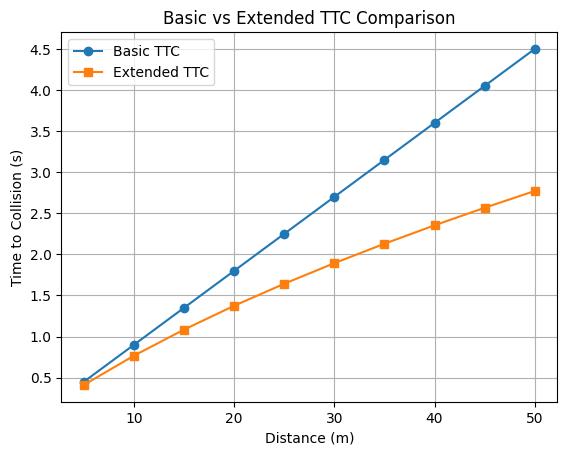

In [20]:
import math
import matplotlib.pyplot as plt

distances = list(range(5,51,5))   # 5m to 50m
speed = 40                        # kmph
deceleration = 5                  # m/s^2

v = speed / 3.6

ttc_basic_list = []
ttc_ext_list = []

for d in distances:
    ttc_basic = d / v
    ttc_ext = (-v + math.sqrt(v*v + 2*deceleration*d)) / deceleration
    
    ttc_basic_list.append(ttc_basic)
    ttc_ext_list.append(ttc_ext)

plt.plot(distances, ttc_basic_list, marker='o', label="Basic TTC")
plt.plot(distances, ttc_ext_list, marker='s', label="Extended TTC")

plt.xlabel("Distance (m)")
plt.ylabel("Time to Collision (s)")
plt.title("Basic vs Extended TTC Comparison")
plt.legend()
plt.grid()

plt.show()

In [21]:
components = [
    "ESP32 DevKit V1",
    "HC-SR04 Ultrasonic Sensor (2 units)",
    "VL53L1X LiDAR Sensor",
    "MPU6050 IMU",
    "Rotary Encoder",
    "0.96 inch OLED Display",
    "5 LEDs (2 Green, 2 Yellow, 1 Red)",
    "Active Buzzer",
    "Breadboard",
    "Jumper wires",
    "Resistors (220 ohm)",
    "Power bank or USB supply"
]

print("Component Purchase Checklist:\n")

for c in components:
    print("-", c)

Component Purchase Checklist:

- ESP32 DevKit V1
- HC-SR04 Ultrasonic Sensor (2 units)
- VL53L1X LiDAR Sensor
- MPU6050 IMU
- Rotary Encoder
- 0.96 inch OLED Display
- 5 LEDs (2 Green, 2 Yellow, 1 Red)
- Active Buzzer
- Breadboard
- Jumper wires
- Resistors (220 ohm)
- Power bank or USB supply


In [22]:
sample = [[40, 20, 10, 2.5, 0]]   # speed, distance, closing_vel, ttc, road

pred = model.predict(sample)

print("Predicted Risk Class =", pred[0])

Predicted Risk Class = 1


C:\Users\niroo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd

sample = pd.DataFrame(
    [[40,20,10,2.5,0]],
    columns=["speed","distance","closing_vel","ttc","road"]
)

pred = model.predict(sample)

print("Predicted Risk Class =", pred[0])

Predicted Risk Class = 1


In [24]:
import joblib

joblib.dump(model, "ml_model.pkl")

print("Model saved")

Model saved
